# Practice Lab: Regularization with Ridge, Lasso, and ElasticNet

We are tackling a common problem in Data Science: **Multicollinearity** (when your features are highly correlated with each other) and **Overfitting**. 

To solve this, we will use **Regularization**, which penalizes complex models. You will build and compare four models:
1. Standard Linear Regression (Base Model)
2. Ridge Regression ($L_2$ Penalty)
3. Lasso Regression ($L_1$ Penalty)
4. ElasticNet (Combination of $L_1$ and $L_2$)

### Abalone & The Business Problem
We will use the famous Abalone dataset to predict the age of an abalone (a highly valued marine snail) based on its physical measurements. 

**Why does predicting their age matter?**

Abalones are a premium seafood delicacy, making them vulnerable to overfishing. Strict regulations are in place to ensure abalones are only harvested after they reach a certain age, allowing them time to reproduce. Furthermore, aquaculture farms need to track age to optimize feeding and harvest times for profit. 

Currently, determining an abalone's age is a destructive, expensive, and tedious process: it requires cutting the shell, staining it, and counting the rings under a microscope. **Our goal is to build a Machine Learning model that can predict the age (number of rings) using simple, non-destructive measurements like weight and length.** If successful, we can save fisheries time and money!

**Data Dictionary:**
|Column| Definition |
|------|------------|
|`Sex`|: M (Male), F (Female), I (Infant)|
|`Length`|: Longest shell measurement (mm)|
|`Diameter`|: Perpendicular to length (mm)|
|`Height`|: With meat in shell (mm)|
|`Whole_weight`|: Whole abalone (grams)|
|`Shucked_weight`|: Weight of meat (grams)|
|`Viscera_weight`|: Gut weight after bleeding (grams)|
|`Shell_weight`|: After being dried (grams)|
|`Class` (Target)|: Number of rings. *Note: Age is roughly rings + 1.5 years.*|

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

## 1. Load the Data
We will fetch the Abalone dataset directly from OpenML.

In [4]:
# Fetch Abalone dataset (version 1)
abalone = fetch_openml(name="abalone", version=1, as_frame=True, parser='auto')
df = abalone.frame

# Rename the target column from 'Class' to 'Rings' for clarity
df = df.rename(columns={'Class_number_of_rings': 'Rings'})

# Display the first 5 rows
df.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


## 2. Exploratory Data Analysis (EDA)
Before modeling, let's understand our data. Regularization is especially useful when features are highly correlated. Let's prove that this dataset has high multicollinearity.

In [5]:
# TODO: Check for missing values in the dataframe
df.isnull().sum()

Sex               0
Length            0
Diameter          0
Height            0
Whole_weight      0
Shucked_weight    0
Viscera_weight    0
Shell_weight      0
Rings             0
dtype: int64

**Observation:** There are no missing values in the dataset, so no missing-value treatment is required.

In [6]:
# TODO: Create a correlation matrix for the NUMERICAL features only.
# and NOTE down your observation!
# Hint: Drop the 'Sex' column temporarily or select only numeric columns.
# Optional but recommended: Plot this using sns.heatmap()



# Select numerical columns only
numeric_df = df.select_dtypes(include='number')

# Correlation matrix
corr_matrix = numeric_df.corr()

corr_matrix

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight
Length,1.000000,0.986812,0.827554,0.925261,0.897914,0.903018,0.897706
Diameter,0.986812,1.000000,0.833684,0.925452,0.893162,0.899724,0.905330
Height,0.827554,0.833684,1.000000,0.819221,0.774972,0.798319,0.817338
Whole_weight,0.925261,0.925452,0.819221,1.000000,0.969405,0.966375,0.955355
Shucked_weight,0.897914,0.893162,0.774972,0.969405,1.000000,0.931961,0.882617
Viscera_weight,0.903018,0.899724,0.798319,0.966375,0.931961,1.000000,0.907656
Shell_weight,0.897706,0.905330,0.817338,0.955355,0.882617,0.907656,1.000000


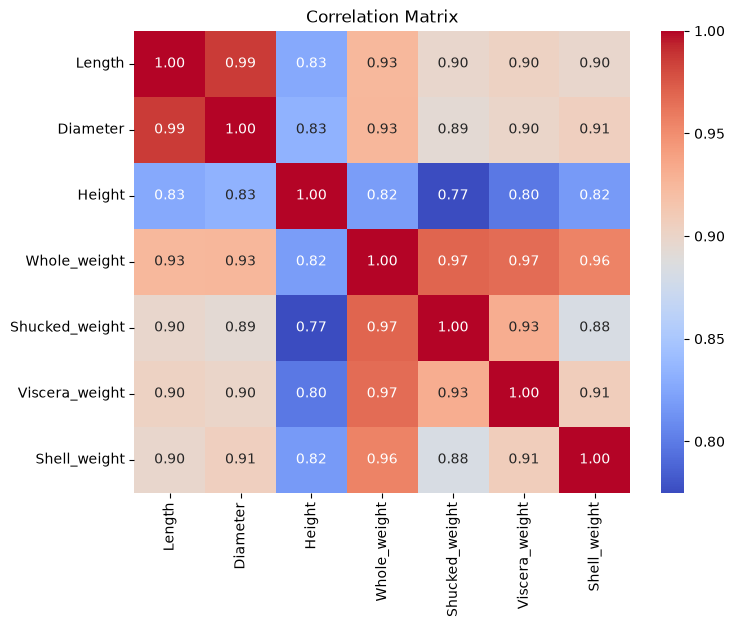

In [8]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

### Observation

The correlation matrix shows that many numerical features are highly correlated with each other. For example, `Length` and `Diameter` have a correlation of about 0.99, while `Whole_weight` is also highly correlated with `Shucked_weight`, `Viscera_weight`, and `Shell_weight` (around 0.96–0.97).

This indicates strong multicollinearity in the dataset, making it a good candidate for regularization techniques such as Ridge, Lasso, and ElasticNet.

## 3. Data Preprocessing
Machine Learning models need numbers, not text. We need to handle the categorical `Sex` column and split our data. 

**Crucial Note for Regularization:** You MUST scale your features when using Ridge, Lasso, or ElasticNet. Because regularization penalizes the size of the coefficients, features on larger scales (like thousands) will be penalized unfairly compared to features on smaller scales (like decimals) if they aren't standardized first.

In [10]:
# TODO: One-hot encode the 'Sex' column using pd.get_dummies() or One-hot Encoding. 
# Hint: Use drop_first=True to avoid the dummy variable trap.

# One-hot encode the 'Sex' column
df = pd.get_dummies(df, columns=['Sex'], drop_first=True)

df.head()

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings,Sex_I,Sex_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15,False,True
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7,False,True
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9,False,False
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10,False,True
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7,True,False


In [11]:
# TODO: Separate your features (X) and target (y)

# Separate features (X) and target (y)

X = df.drop(columns='Rings')
y = df['Rings']

print(X.head())
print(y.head())


   Length  Diameter  Height  Whole_weight  Shucked_weight  Viscera_weight  \
0   0.455     0.365   0.095        0.5140          0.2245          0.1010   
1   0.350     0.265   0.090        0.2255          0.0995          0.0485   
2   0.530     0.420   0.135        0.6770          0.2565          0.1415   
3   0.440     0.365   0.125        0.5160          0.2155          0.1140   
4   0.330     0.255   0.080        0.2050          0.0895          0.0395   

   Shell_weight  Sex_I  Sex_M  
0         0.150  False   True  
1         0.070  False   True  
2         0.210  False  False  
3         0.155  False   True  
4         0.055   True  False  
0    15
1     7
2     9
3    10
4     7
Name: Rings, dtype: category
Categories (28, str): ['1', '10', '11', '12', ..., '6', '7', '8', '9']


In [12]:
# TODO: Perform a train_test_split. Use a test_size of 0.2 and random_state of 10.

# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=10
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(3341, 9)
(836, 9)
(3341,)
(836,)


In [13]:
# TODO: Initialize the StandardScaler

scaler = StandardScaler()

# TODO: Fit the scaler on the training data AND transform X_train. 
X_train_scaled = scaler.fit_transform(X_train)

# TODO: Transform the test data (Do NOT fit the scaler on the test data!)
X_test_scaled = scaler.transform(X_test)
print(X_train_scaled.shape)
print(X_test_scaled.shape)


(3341, 9)
(836, 9)


## 4. Don't Repeat Yourself (DRY): Evaluation Function
As good programmers, we want to avoid writing the same evaluation code four times. 

Write a function that takes in a fitted model, the training data, and the testing data, and prints out the $R^2$ and Root Mean Squared Error (RMSE) for BOTH the training and test sets. Comparing train vs. test metrics helps us spot overfitting!

*__Note__: You can add this to your go-to function toolbox!*

In [18]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    """
    Predicts and calculates R2 and RMSE for both train and test sets.
    Then prints the Train R2 and RMSE along with the Test R2 and RMSE.
    """

    print(f"--- {model_name} Performance ---")

    # TODO: Generate predictions for both X_train and X_test
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # TODO: Calculate R2 for train and test
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # TODO: Calculate RMSE for train and test
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    # TODO: Print the results clearly
    print(f"Train R² : {train_r2:.4f}")
    print(f"Train RMSE : {train_rmse:.4f}")
    print(f"Test R² : {test_r2:.4f}")
    print(f"Test RMSE : {test_rmse:.4f}")

## 5. Base Model: Standard Linear Regression
Let's see how a standard linear regression model handles this highly correlated data.

In [19]:
# TODO: Initialize and fit a standard Linear Regression model on the SCALED training data

linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)


# TODO: Use your custom evaluate_model() function to check its performance

evaluate_model(
    linear_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    model_name="Linear Regression"
)

--- Linear Regression Performance ---
Train R² : 0.5349
Train RMSE : 2.2113
Test R² : 0.5497
Test RMSE : 2.1116


## 6. Regularization Models
Now, let's apply penalties to our model to handle the multicollinearity.

Instead of guessing the penalty term (`alpha`), we will use Scikit-Learn's built-in Cross-Validation models (`RidgeCV`, `LassoCV`, `ElasticNetCV`). These models automatically try a list of different alphas and select the one that performs best!

### RIDGE REGRESSION (L2 Penalty)

In [8]:
# We provide a list of alphas to test (from very small to very large)
alphas_to_test = [0.01, 0.1, 1.0, 10.0, 100.0]

# TODO: Initialize RidgeCV with the alphas_to_test, cv=5, random_state=10 and fit it to the training data


# TODO: Use evaluate_model() to check performance

# TODO: Print the best alpha found by RidgeCV (Hint: look up the .alpha_ attribute)


### LASSO REGRESSION (L1 Penalty)

__Note__: You can provide a custom list to `LassoCV` and `ElasticNetCV` if you want to, but it is generally best practice to leave it blank and let Scikit-Learn automatically calculate the optimal path for you.

In [20]:
# We provide a list of alphas to test (from very small to very large)
alphas_to_test = [0.01, 0.1, 1.0, 10.0, 100.0]

# TODO: Initialize RidgeCV with the alphas_to_test, cv=5, random_state=10 and fit it to the training data

ridge_model = RidgeCV(
    alphas=alphas_to_test,
    cv=5
)

ridge_model.fit(X_train_scaled, y_train)


# TODO: Use evaluate_model() to check performance

evaluate_model(
    ridge_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    model_name="Ridge Regression"
)


# TODO: Print the best alpha found by RidgeCV (Hint: look up the .alpha_ attribute)

print("Best alpha found by RidgeCV:", ridge_model.alpha_)

--- Ridge Regression Performance ---
Train R² : 0.5349
Train RMSE : 2.2114
Test R² : 0.5497
Test RMSE : 2.1118
Best alpha found by RidgeCV: 1.0


### ELASTICNET REGRESSION (L1 + L2 Penalty)

In [21]:
# TODO: Initialize LassoCV (you can let it choose alphas automatically by not passing any), cv=5, random_state=10
# and fit it to the training data

lasso_model = LassoCV(
    cv=5,
    random_state=10
)

lasso_model.fit(X_train_scaled, y_train)


# TODO: Use evaluate_model() to check performance

evaluate_model(
    lasso_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    model_name="Lasso Regression"
)


# TODO: Print the best alpha found by LassoCV

print("Best alpha found by LassoCV:", lasso_model.alpha_)

--- Lasso Regression Performance ---
Train R² : 0.5347
Train RMSE : 2.2118
Test R² : 0.5493
Test RMSE : 2.1126
Best alpha found by LassoCV: 0.003102557702171799


In [22]:
# TODO: Initialize ElasticNetCV with cv=5, random_state=10 and fit it to the training data

elastic_model = ElasticNetCV(
    cv=5,
    random_state=10
)

elastic_model.fit(X_train_scaled, y_train)


# TODO: Use evaluate_model() to check performance

evaluate_model(
    elastic_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    model_name="ElasticNet Regression"
)


# TODO: Print the best alpha found by ElasticNetCV

print("Best alpha found by ElasticNetCV:", elastic_model.alpha_)

--- ElasticNet Regression Performance ---
Train R² : 0.5335
Train RMSE : 2.2148
Test R² : 0.5480
Test RMSE : 2.1156
Best alpha found by ElasticNetCV: 0.004082551587352136


## 7. Feature Selection with Lasso
One of the superpower traits of Lasso ($L_1$ regularization) is that it can shrink the coefficients of useless or highly correlated features down to **exactly zero**. This acts as automatic feature selection.

Let's look at the coefficients of our models to see this in action.

In [51]:
# Provided Code: Run this cell to compare coefficients!
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Linear_Coef': lr_model.coef_,       # Update 'lr_model' if you named your Linear Regression variable differently
    'Ridge_Coef': ridge_model.coef_,     # Update 'ridge_model' if needed
    'Lasso_Coef': lasso_model.coef_,      # Update 'lasso_model' if needed
    'ElasticNet_Coef': elasticnet_model.coef_
})

# Display the coefficients
coef_df.round(3)

,Feature,Linear_Coef,Ridge_Coef,Lasso_Coef,ElasticNet_Coef
0,Length,0.020,0.025,0.000,0.029
1,Diameter,0.984,0.976,0.981,0.942
2,Height,0.440,0.441,0.437,0.442
3,Whole_weight,4.385,4.202,3.955,3.161
4,Shucked_weight,-4.370,-4.283,-4.168,-3.776
5,Viscera_weight,-1.125,-1.083,-0.987,-0.817
6,Shell_weight,1.254,1.315,1.382,1.640
7,Sex_I,-0.388,-0.390,-0.389,-0.396
8,Sex_M,0.012,0.012,0.008,0.006


__Q1. Which feature(s) did Lasso completely drop (set to 0)?__ 

**Answer:** Lasso completely dropped the `Length` feature by shrinking its coefficient to 0.


__Q2. How does ElasticNet compare to Lasso and Ridge here?__

**Answer:** ElasticNet combines the behavior of both Ridge and Lasso. Unlike Lasso, it did not reduce any feature coefficient completely to zero, but it shrank the coefficients more than Ridge. This allows ElasticNet to perform regularization while keeping all features in the model.




## 8. Communicating Results to Stakeholders

**Scenario:** 
Imagine you are presenting these findings to the manager of a seafood fishery. They have no background in data science or math. They want to know if they can trust this model to replace the manual, time-consuming process of cutting abalone shells and counting rings under a microscope. 

**How to phrase your answer:**
When speaking to stakeholders, avoid throwing raw math at them. Translate the metrics into real-world impact. 

*Example using a Real Estate Model:*
*   ❌ **Bad:** "The model has an RMSE of 25000 and an $R^2$ of 0.85."
*   ✅ **Good:** "Our model is highly accurate, capturing about 85% of the factors that drive house prices. When it makes a prediction, it is typically off by about $25,000 on average."

**Your Task:**
Double-click this text cell. Based on your best model's RMSE and $R^2$ scores, write a 3-4 sentence explanation answering the fishery manager's question. Be honest about whether the model is accurate enough to replace humans entirely, or if it should just be used as an estimation tool.


> Our model can estimate the age of an abalone using simple physical measurements instead of the traditional manual process. On average, the prediction is off by about 2 rings, so it provides a useful estimate but is not perfectly accurate. This makes the model a valuable tool for saving time and supporting decision-making, but it should be used alongside expert judgment rather than completely replacing manual inspection.

# Now it’s your turn!
1. Derive at least one new feature that adds value to the dataset.
2. Apply a feature selection technique to eliminate uninformative variables.
3. Document your reasoning in clean Markdown cells as you go!

In [23]:
# Create a new feature

df['Meat_Ratio'] = df['Shucked_weight'] / df['Whole_weight']

df[['Whole_weight', 'Shucked_weight', 'Meat_Ratio']].head()

,Whole_weight,Shucked_weight,Meat_Ratio
0,0.5140,0.2245,0.436770
1,0.2255,0.0995,0.441242
2,0.6770,0.2565,0.378877
3,0.5160,0.2155,0.417636
4,0.2050,0.0895,0.436585


### New Feature

A new feature called `Meat_Ratio` was created by dividing `Shucked_weight` by `Whole_weight`. This feature represents the proportion of edible meat relative to the total weight and may help the model better estimate the age of the abalone.

In [24]:
# Feature selection using Lasso results

selected_features = [
    feature
    for feature, coef in zip(X.columns, lasso_model.coef_)
    if coef != 0
]

print("Selected Features:")
print(selected_features)

Selected Features:
['Diameter', 'Height', 'Whole_weight', 'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Sex_I', 'Sex_M']


### Feature Selection

Lasso was used for feature selection because it can shrink less important feature coefficients to zero. Based on the Lasso results, the `Length` feature was removed, while the remaining features were retained for modeling.